In [2]:
pip install pandas numpy nltk gensim matplotlib wordcloud scikit-learn

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 5.6 MB/s eta 0:00:01
   --------------------------------- ------ 1.3/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 5.6 MB/s eta 0:00:05
   -- ------------------------------------- 1.6/24.4 MB 3.5 MB/s eta 0:00:07
   ----- ---------------------------------- 3.1/24.4 MB 4.9 MB/s eta 0:00:05
   ------ --------------------------------- 3.9/24.4 MB 4.4 MB/s eta 0:00:05
   ------ --------------------------------- 4.2/24.4 MB 4.4 MB/s eta 0:00:05
   ------ --------------------------------- 4.2/24.4 MB 4.4 MB/s eta 0:00:05
   ------ --------------------------------- 4.2/24.4 MB 4.4 MB/s eta 0:00:05
   ------ --------------------------------- 4.2/24.4 MB 4.4 MB/s eta 0:00:05
   -------- -----


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Yugesh\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Topics:

Topic 0: 0.064*"machine" + 0.063*"ai" + 0.063*"artificial" + 0.063*"transforming" + 0.063*"industries" + 0.063*"intelligence" + 0.063*"advancements" + 0.063*"technology" + 0.063*"robotics" + 0.063*"learning"
Topic 1: 0.101*"sports" + 0.058*"millions" + 0.058*"events" + 0.058*"olympics" + 0.058*"fifa" + 0.058*"like" + 0.058*"attract" + 0.058*"popular" + 0.058*"worldwide" + 0.058*"football"
Topic 2: 0.087*"learning" + 0.049*"includes" + 0.049*"neural" + 0.049*"deep" + 0.049*"science" + 0.049*"networks" + 0.049*"subsets" + 0.049*"statistics" + 0.049*"data" + 0.049*"games"


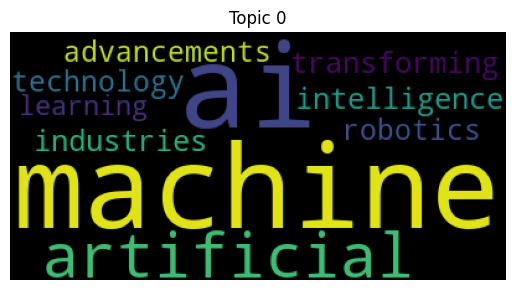

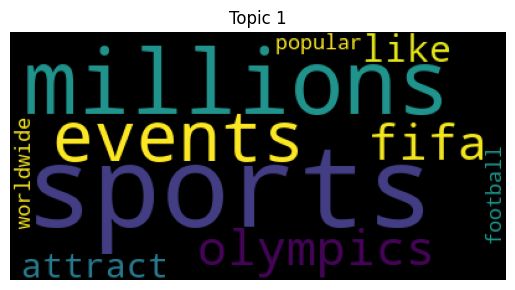

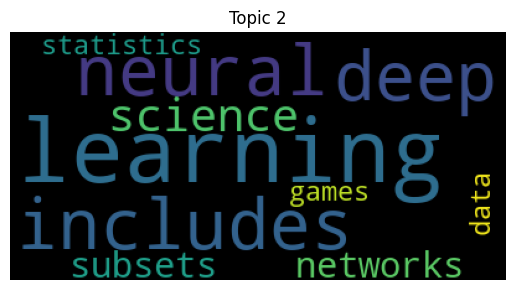

In [3]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaModel
from wordcloud import WordCloud

nltk.download('stopwords')

# Sample dataset
data = [
    "Artificial intelligence and machine learning are transforming industries",
    "Football and cricket are popular sports worldwide",
    "Technology advancements in AI and robotics",
    "Sports events like Olympics and FIFA attract millions",
    "Deep learning and neural networks are subsets of AI",
    "Basketball and tennis are famous games",
    "Data science includes machine learning and statistics"
]

df = pd.DataFrame(data, columns=['text'])

# Preprocessing
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

df['processed'] = df['text'].apply(clean_text)

# Create Dictionary & Corpus
dictionary = corpora.Dictionary(df['processed'])
corpus = [dictionary.doc2bow(text) for text in df['processed']]

# Train LDA Model
lda_model = LdaModel(corpus=corpus,
                     id2word=dictionary,
                     num_topics=3,
                     random_state=42,
                     passes=10)

# Print Topics
print("Topics:\n")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# Visualization - WordCloud
for i in range(3):
    words = dict(lda_model.show_topic(i, 10))
    wc = WordCloud().generate_from_frequencies(words)
    
    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Topic {i}")
    plt.show()